## **Import Packages**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from matplotlib.dates import DateFormatter


In [13]:
df = pd.read_csv('usd_exchange_rates.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df.sort_index()

In [14]:
df.head()

,bid,ask,mid
date,,,
2025-05-02,26.1488,27.4898,26.8193
2025-05-05,26.1503,27.4913,26.8208
2025-05-06,26.1565,27.4979,26.8272
2025-05-07,26.1599,27.5015,26.8307
2025-05-08,26.1629,27.5045,26.8337


In [15]:
df.shape

(86, 3)

In [16]:
df.describe()

,bid,ask,mid
count,86.000000,86.000000,86.000000
mean,26.183372,27.526119,26.854747
std,0.077116,0.081076,0.079094
min,26.067300,27.404100,26.735700
25%,26.112550,27.451650,26.782100
50%,26.172250,27.514450,26.843350
75%,26.256125,27.602625,26.929375
max,26.321600,27.671400,26.996500


In [17]:
percentage_missing = df.isnull().mean() * 100
percentage_missing

bid    0.0
ask    0.0
mid    0.0
dtype: float64

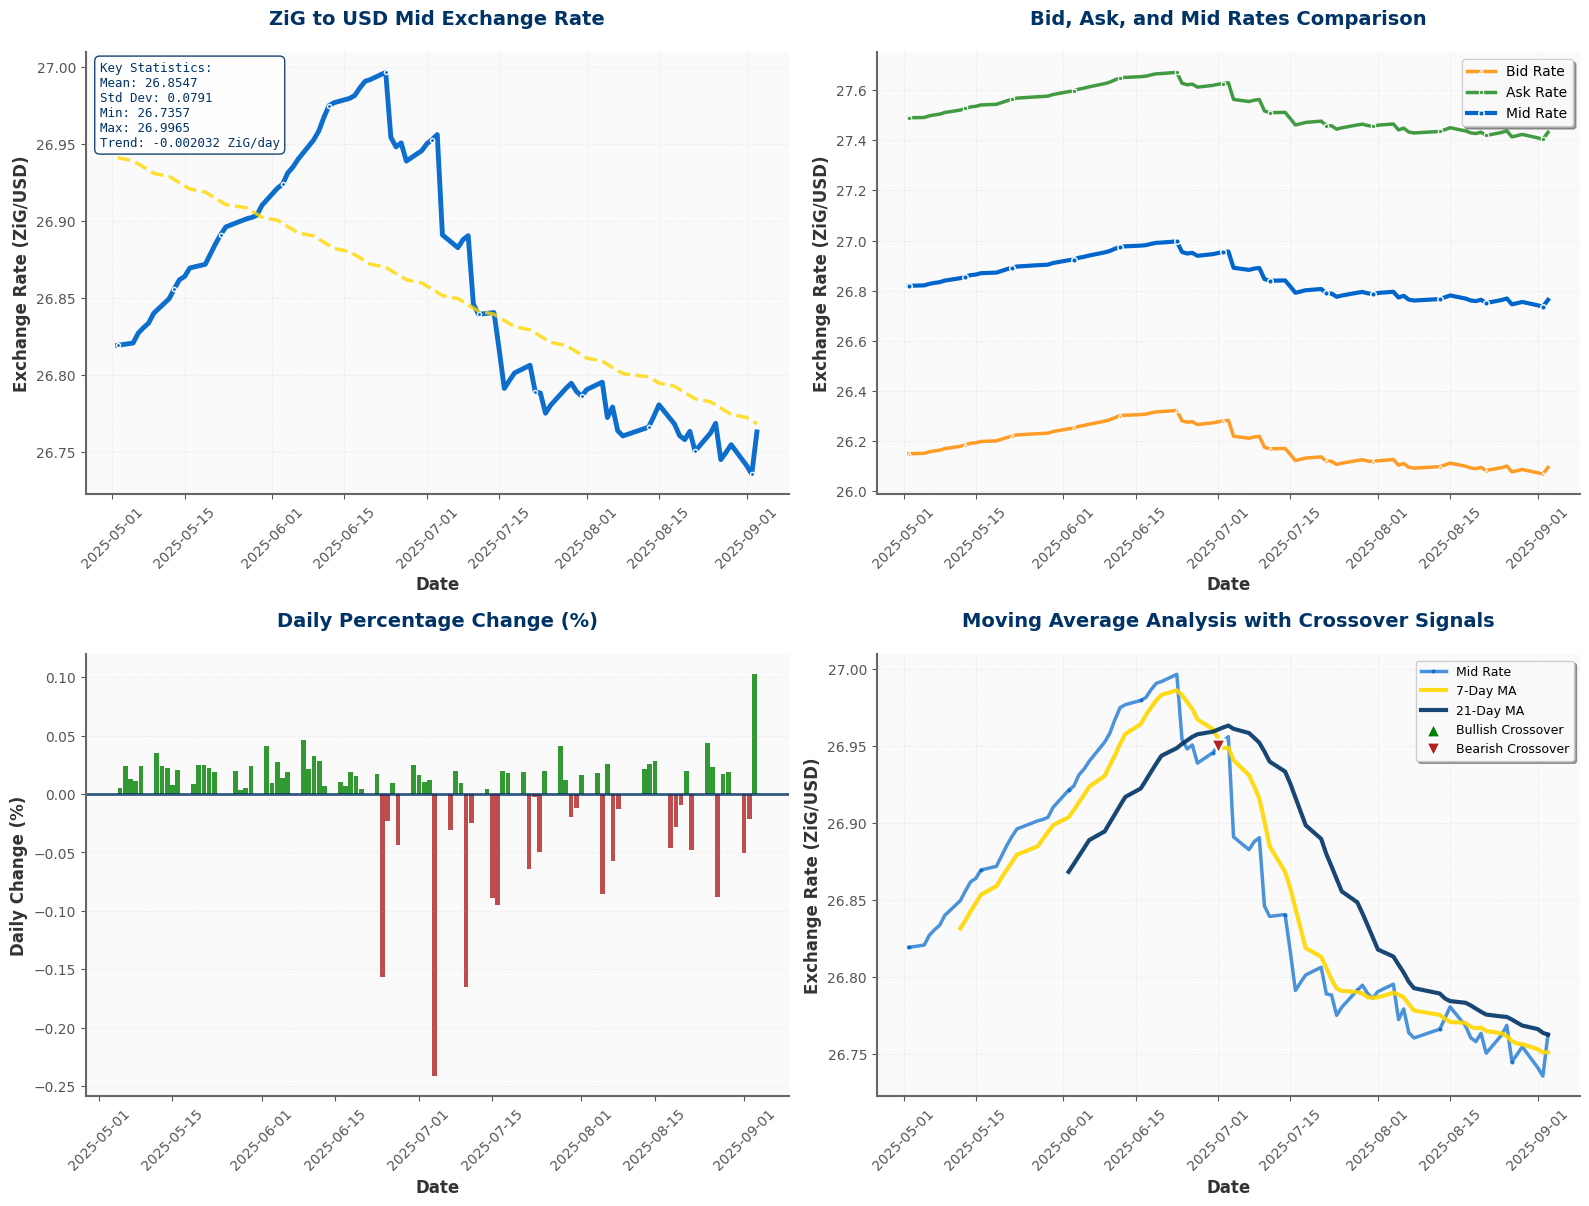

In [ ]:

plt.style.use('default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2  


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

primary_blue = '#003366'   
secondary_gold = '#FFD700'  
accent_green = '#008000'    
mid_color = '#0066CC'       
bid_color = '#FF8C00'       
ask_color = '#228B22'     


axes[0, 0].plot(df.index, df['mid'], linewidth=3.5, color=mid_color, alpha=0.95, 
               marker='o', markersize=3, markeredgecolor='white', markeredgewidth=1,
               markerfacecolor=mid_color, markevery=7)
axes[0, 0].set_title('ZiG to USD Mid Exchange Rate', fontsize=14, 
                    fontweight='bold', pad=20, color=primary_blue)
axes[0, 0].set_xlabel('Date', fontsize=12, color='#333333', fontweight='bold')
axes[0, 0].set_ylabel('Exchange Rate (ZiG/USD)', fontsize=12, color='#333333', fontweight='bold')
axes[0, 0].grid(True, alpha=0.15, linestyle='--', linewidth=0.7)
axes[0, 0].tick_params(axis='x', rotation=45, colors='#555555', labelsize=10)
axes[0, 0].tick_params(axis='y', colors='#555555', labelsize=10)


z = np.polyfit(range(len(df)), df['mid'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df.index, p(range(len(df))), '--', color=secondary_gold, 
               linewidth=2.5, alpha=0.8, label='Trend')


axes[0, 1].plot(df.index, df['bid'], label='Bid Rate', alpha=0.85, linewidth=2.5, 
               color=bid_color, marker='^', markersize=3, markevery=7, markeredgecolor='white')
axes[0, 1].plot(df.index, df['ask'], label='Ask Rate', alpha=0.85, linewidth=2.5, 
               color=ask_color, marker='s', markersize=3, markevery=7, markeredgecolor='white')
axes[0, 1].plot(df.index, df['mid'], label='Mid Rate', linewidth=3, color=mid_color,
               marker='o', markersize=4, markevery=7, markeredgecolor='white')
axes[0, 1].set_title('Bid, Ask, and Mid Rates Comparison', fontsize=14, fontweight='bold', 
                    pad=20, color=primary_blue)
axes[0, 1].set_xlabel('Date', fontsize=12, color='#333333', fontweight='bold')
axes[0, 1].set_ylabel('Exchange Rate (ZiG/USD)', fontsize=12, color='#333333', fontweight='bold')
axes[0, 1].legend(frameon=True, fancybox=True, shadow=True, 
                loc='best', framealpha=0.95, fontsize=10)
axes[0, 1].grid(True, alpha=0.15, linestyle='--', linewidth=0.7)
axes[0, 1].tick_params(axis='x', rotation=45, colors='#555555', labelsize=10)
axes[0, 1].tick_params(axis='y', colors='#555555', labelsize=10)


daily_returns = df['mid'].pct_change().dropna() * 100
colors = [accent_green if x >= 0 else '#B22222' for x in daily_returns]  
bars = axes[1, 0].bar(daily_returns.index, daily_returns, color=colors, alpha=0.8,
                     edgecolor='none', linewidth=0, width=0.9)
axes[1, 0].axhline(y=0, color=primary_blue, linestyle='-', alpha=0.8, linewidth=2)
axes[1, 0].set_title('Daily Percentage Change (%)', fontsize=14, fontweight='bold',
                    pad=20, color=primary_blue)
axes[1, 0].set_xlabel('Date', fontsize=12, color='#333333', fontweight='bold')
axes[1, 0].set_ylabel('Daily Change (%)', fontsize=12, color='#333333', fontweight='bold')
axes[1, 0].grid(True, alpha=0.15, linestyle='--', linewidth=0.7, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45, colors='#555555', labelsize=10)
axes[1, 0].tick_params(axis='y', colors='#555555', labelsize=10)


short_ma = df['mid'].rolling(window=7).mean() 
long_ma = df['mid'].rolling(window=21).mean()   

axes[1, 1].plot(df.index, df['mid'], linewidth=2.5, color=mid_color, alpha=0.7, 
               label='Mid Rate', marker='o', markersize=2, markevery=10)
axes[1, 1].plot(df.index, short_ma, linewidth=3, color=secondary_gold, 
               label='7-Day MA', alpha=0.9)
axes[1, 1].plot(df.index, long_ma, linewidth=3, color=primary_blue, 
               label='21-Day MA', alpha=0.9)


crossover_up = (short_ma > long_ma) & (short_ma.shift(1) <= long_ma.shift(1))
crossover_down = (short_ma < long_ma) & (short_ma.shift(1) >= long_ma.shift(1))

up_points = df.index[crossover_up]
down_points = df.index[crossover_down]

axes[1, 1].scatter(up_points, df['mid'][crossover_up], color=accent_green, 
                  s=100, marker='^', edgecolor='white', linewidth=1.5, 
                  label='Bullish Crossover', zorder=5)
axes[1, 1].scatter(down_points, df['mid'][crossover_down], color='#B22222', 
                  s=100, marker='v', edgecolor='white', linewidth=1.5, 
                  label='Bearish Crossover', zorder=5)

axes[1, 1].set_title('Moving Average Analysis with Crossover Signals', fontsize=14, 
                    fontweight='bold', pad=20, color=primary_blue)
axes[1, 1].set_xlabel('Date', fontsize=12, color='#333333', fontweight='bold')
axes[1, 1].set_ylabel('Exchange Rate (ZiG/USD)', fontsize=12, color='#333333', fontweight='bold')
axes[1, 1].grid(True, alpha=0.15, linestyle='--', linewidth=0.7)
axes[1, 1].legend(frameon=True, fancybox=True, shadow=True, framealpha=0.95, fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=45, colors='#555555', labelsize=10)
axes[1, 1].tick_params(axis='y', colors='#555555', labelsize=10)


for i in range(2):
    for j in range(2):
        axes[i, j].set_facecolor('#fafafa')
    
        axes[i, j].spines['left'].set_linewidth(1.5)
        axes[i, j].spines['bottom'].set_linewidth(1.5)
        axes[i, j].spines['left'].set_color('#666666')
        axes[i, j].spines['bottom'].set_color('#666666')
      
        axes[i, j].spines['top'].set_visible(False)
        axes[i, j].spines['right'].set_visible(False)


stats_text = f"""Key Statistics:
Mean: {df['mid'].mean():.4f}
Std Dev: {df['mid'].std():.4f}
Min: {df['mid'].min():.4f}
Max: {df['mid'].max():.4f}
Trend: {z[0]:.6f} ZiG/day"""
axes[0, 0].text(0.02, 0.98, stats_text, transform=axes[0, 0].transAxes, 
               verticalalignment='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.4", 
               facecolor="white", alpha=0.9, edgecolor=primary_blue), 
               fontfamily='monospace', color=primary_blue)


# fig.text(0.5, 0.01, 'Source: Reserve Bank of Zimbabwe | Official Exchange Rates', 
#          ha='center', alpha=0.8, fontsize=10, color=primary_blue, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.06)
plt.show()

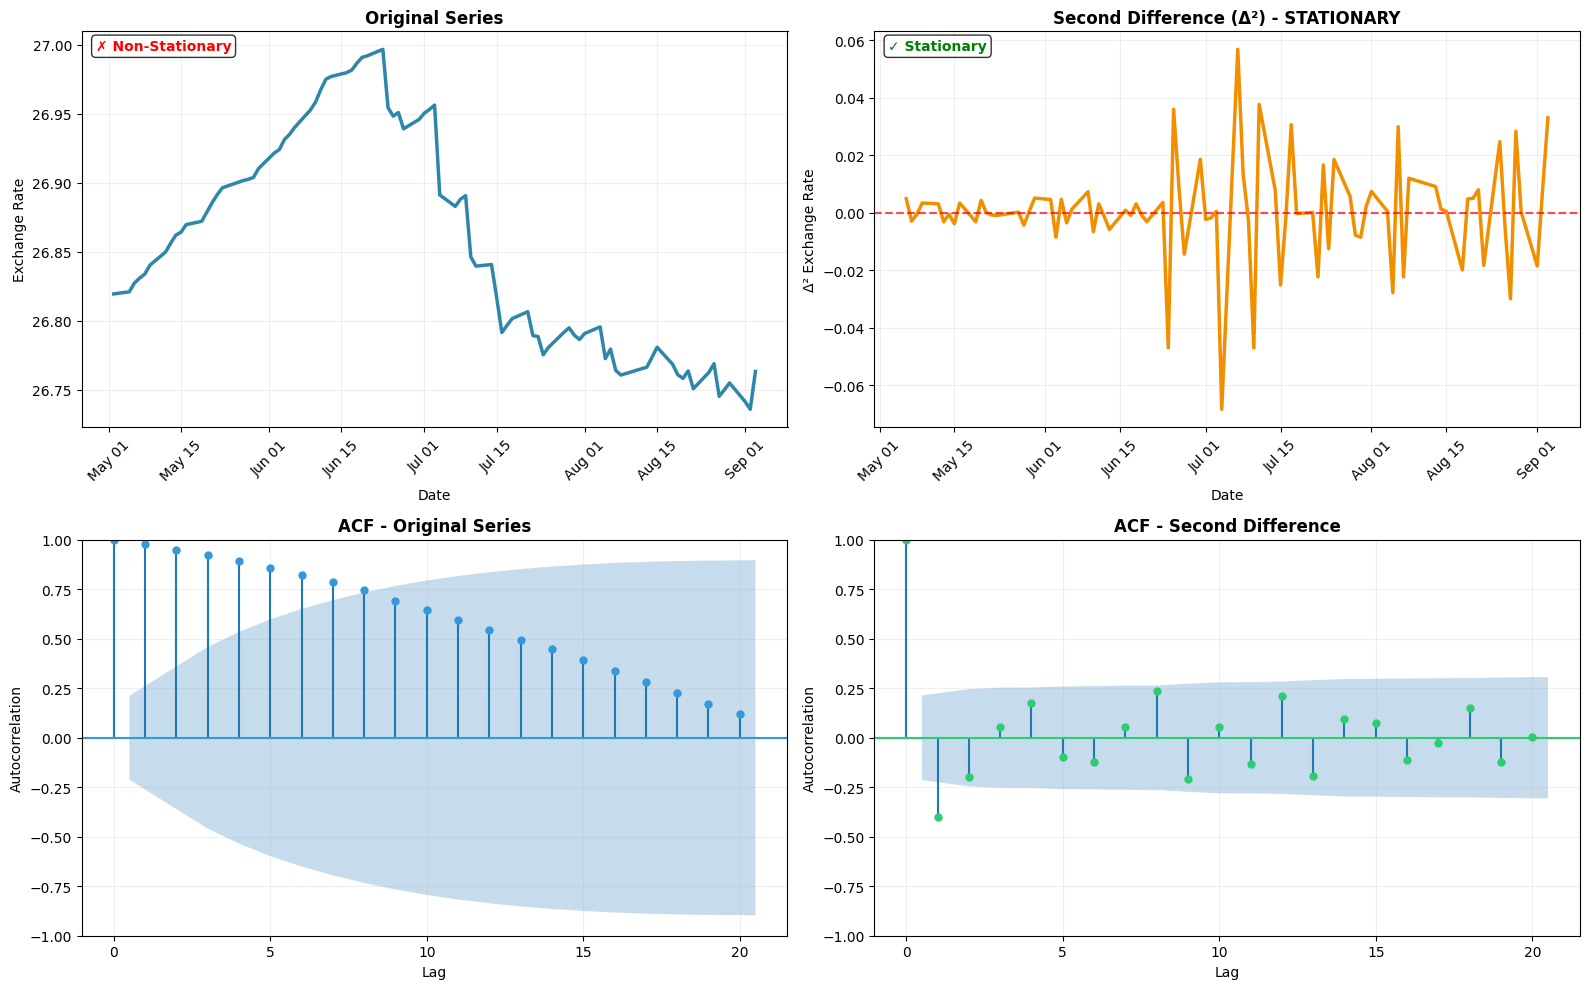

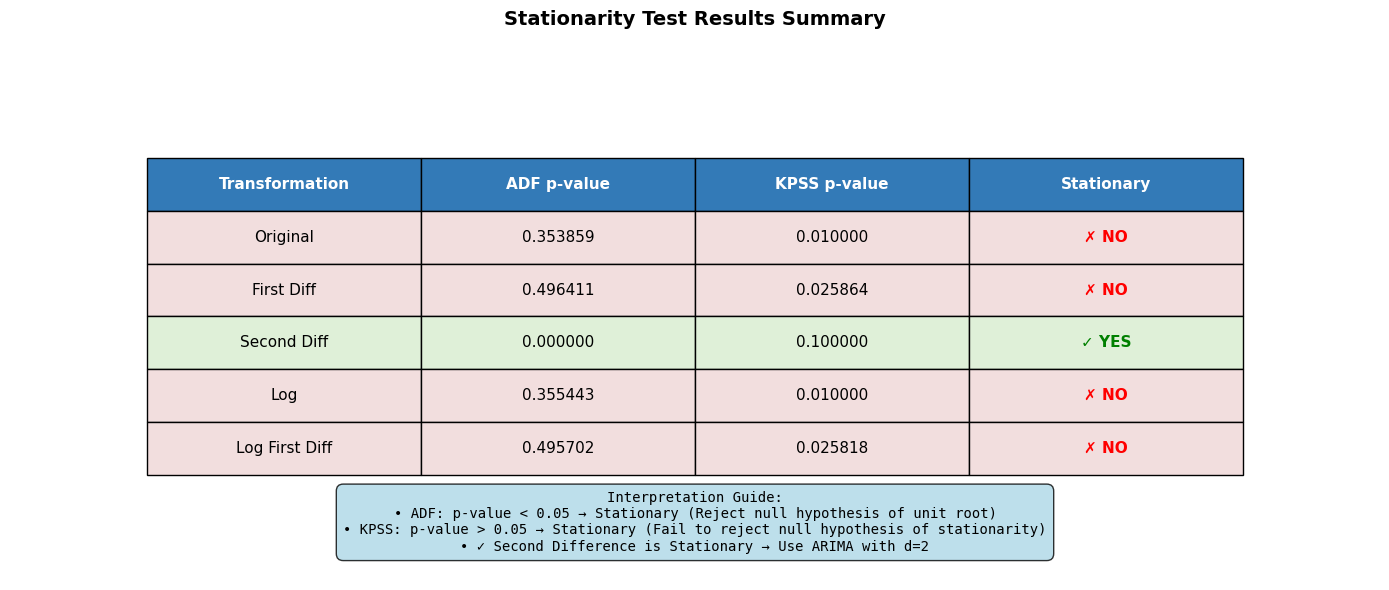


KEY FINDINGS & RECOMMENDATIONS
✓ SECOND DIFFERENCING (d=2) makes the series STATIONARY
✓ This indicates the series is integrated of order 2 (I(2))
✓ ACF of second difference shows significant spike at lag 1
✓ This suggests potential MA(1) component

RECOMMENDED ARIMA MODELS TO START WITH:
• ARIMA(0,2,1) - Moving average model
• ARIMA(1,2,0) - Autoregressive model
• ARIMA(1,2,1) - Mixed ARMA model
• ARIMA(2,2,1) - Higher order model

NEXT STEPS:
• Use AIC/BIC for model selection
• Validate with out-of-sample testing
• Monitor residuals for white noise
• Consider economic variables for multivariate analysis


In [ ]:
plt.style.use('default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

date_formatter = DateFormatter('%b %d')


axes[0, 0].plot(df['mid'], color='#2E86AB', linewidth=2.5)
axes[0, 0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Exchange Rate', fontsize=10)
axes[0, 0].grid(True, alpha=0.2)
axes[0, 0].text(0.02, 0.98, '✗ Non-Stationary', transform=axes[0, 0].transAxes, 
                fontsize=10, fontweight='bold', color='red', verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

axes[0, 0].xaxis.set_major_formatter(date_formatter)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_xlabel('Date', fontsize=10)

second_diff = df['mid'].diff().diff().dropna()
axes[0, 1].plot(second_diff.index, second_diff, color='#F18F01', linewidth=2.5)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0, 1].set_title('Second Difference (Δ²) - STATIONARY', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Δ² Exchange Rate', fontsize=10)
axes[0, 1].grid(True, alpha=0.2)
axes[0, 1].text(0.02, 0.98, '✓ Stationary', transform=axes[0, 1].transAxes, 
                fontsize=10, fontweight='bold', color='green', verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

axes[0, 1].xaxis.set_major_formatter(date_formatter)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_xlabel('Date', fontsize=10)

plot_acf(df['mid'].dropna(), ax=axes[1, 0], lags=20, alpha=0.05, color='#3498db')
axes[1, 0].set_title('ACF - Original Series', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.2)
axes[1, 0].set_xlabel('Lag', fontsize=10)
axes[1, 0].set_ylabel('Autocorrelation', fontsize=10)


plot_acf(second_diff, ax=axes[1, 1], lags=20, alpha=0.05, color='#2ecc71')
axes[1, 1].set_title('ACF - Second Difference', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.2)
axes[1, 1].set_xlabel('Lag', fontsize=10)
axes[1, 1].set_ylabel('Autocorrelation', fontsize=10)

plt.tight_layout()
plt.show()


fig2, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')


table_data = []
transformations = [
    ('Original', df['mid']),
    ('First Diff', df['mid'].diff().dropna()),
    ('Second Diff', second_diff),
    ('Log', np.log(df['mid'])),
    ('Log First Diff', np.log(df['mid']).diff().dropna())
]

for title, series in transformations:
    try:
        adf_result = adfuller(series.dropna(), autolag='AIC')
        kpss_result = kpss(series.dropna(), regression='c')
        stationary = (adf_result[1] < 0.05) and (kpss_result[1] > 0.05)
        table_data.append([
            title,
            f"{adf_result[1]:.6f}",
            f"{kpss_result[1]:.6f}",
            '✓ YES' if stationary else '✗ NO'
        ])
    except:
        table_data.append([title, 'N/A', 'N/A', 'N/A'])


table = ax.table(cellText=table_data,
                 colLabels=['Transformation', 'ADF p-value', 'KPSS p-value', 'Stationary'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0.1, 0.2, 0.8, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)


for i in range(len(table_data) + 1):
    for j in range(4):
        if i == 0:  
            table[(i, j)].set_facecolor('#337AB7')
            table[(i, j)].set_text_props(weight='bold', color='white')
        elif table_data[i-1][3] == '✓ YES':
            table[(i, j)].set_facecolor('#DFF0D8')  
            table[(i, 3)].set_text_props(weight='bold', color='green')
        elif table_data[i-1][3] == '✗ NO':
            table[(i, j)].set_facecolor('#F2DEDE')  
            table[(i, 3)].set_text_props(weight='bold', color='red')

ax.set_title('Stationarity Test Results Summary', fontsize=14, fontweight='bold', pad=20)


interpret_text = """Interpretation Guide:
• ADF: p-value < 0.05 → Stationary (Reject null hypothesis of unit root)
• KPSS: p-value > 0.05 → Stationary (Fail to reject null hypothesis of stationarity)
• ✓ Second Difference is Stationary → Use ARIMA with d=2"""

ax.text(0.5, 0.05, interpret_text, transform=ax.transAxes, fontsize=10,
        fontfamily='monospace', verticalalignment='bottom', horizontalalignment='center',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

#  recommendations 
print("\n" + "="*70)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*70)
print("✓ SECOND DIFFERENCING (d=2) makes the series STATIONARY")
print("✓ This indicates the series is integrated of order 2 (I(2))")
print("✓ ACF of second difference shows significant spike at lag 1")
print("✓ This suggests potential MA(1) component")
print("")
print("RECOMMENDED ARIMA MODELS TO START WITH:")
print("• ARIMA(0,2,1) - Moving average model")
print("• ARIMA(1,2,0) - Autoregressive model") 
print("• ARIMA(1,2,1) - Mixed ARMA model")
print("• ARIMA(2,2,1) - Higher order model")
print("")
print("NEXT STEPS:")
print("• Use AIC/BIC for model selection")
print("• Validate with out-of-sample testing")
print("• Monitor residuals for white noise")
print("• Consider economic variables for multivariate analysis")

## **FITTING ARIMA MODEL**

Training data shape: (86,)
Data range: 2025-05-02 00:00:00 to 2025-09-03 00:00:00
Training and evaluating ARIMA models...
ARIMA(0,2,1): AIC=-484.90, BIC=-480.03
ARIMA(1,2,0): AIC=-449.91, BIC=-445.05
ARIMA(1,2,1): AIC=-483.11, BIC=-475.82
ARIMA(0,2,2): AIC=-483.42, BIC=-476.12
ARIMA(2,2,0): AIC=-467.45, BIC=-460.16
ARIMA(2,2,1): AIC=-487.03, BIC=-477.31

Best model: ARIMA(2,2,1) (AIC: -487.03)

ARIMA(2,2,1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:                    mid   No. Observations:                   86
Model:                 ARIMA(2, 2, 1)   Log Likelihood                 247.515
Date:                Thu, 04 Sep 2025   AIC                           -487.029
Time:                        01:36:21   BIC                           -477.306
Sample:                             0   HQIC                          -483.120
                                 - 86                                         
Covariance Type:     

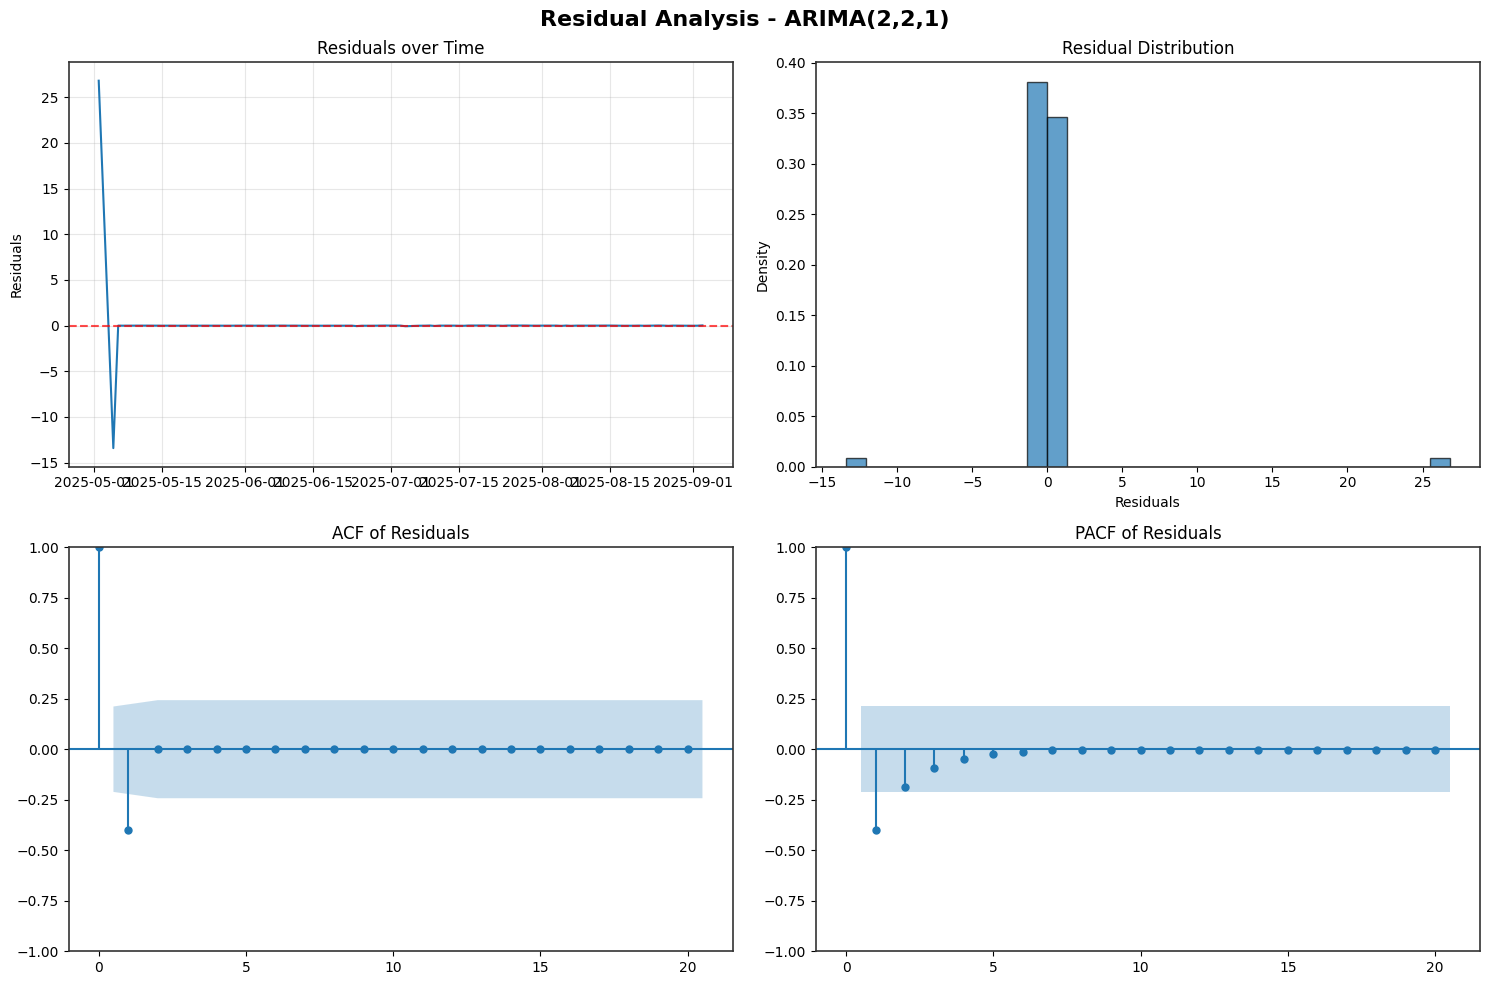


Forecast Summary (Sept 4 - Oct 30, 2025):
Initial forecast (Sept 4): 26.7614
Final forecast (Oct 30): 26.7864
Average forecast: 26.7715
Forecast range: 26.7543 to 26.7864
Trend direction: UPWARD


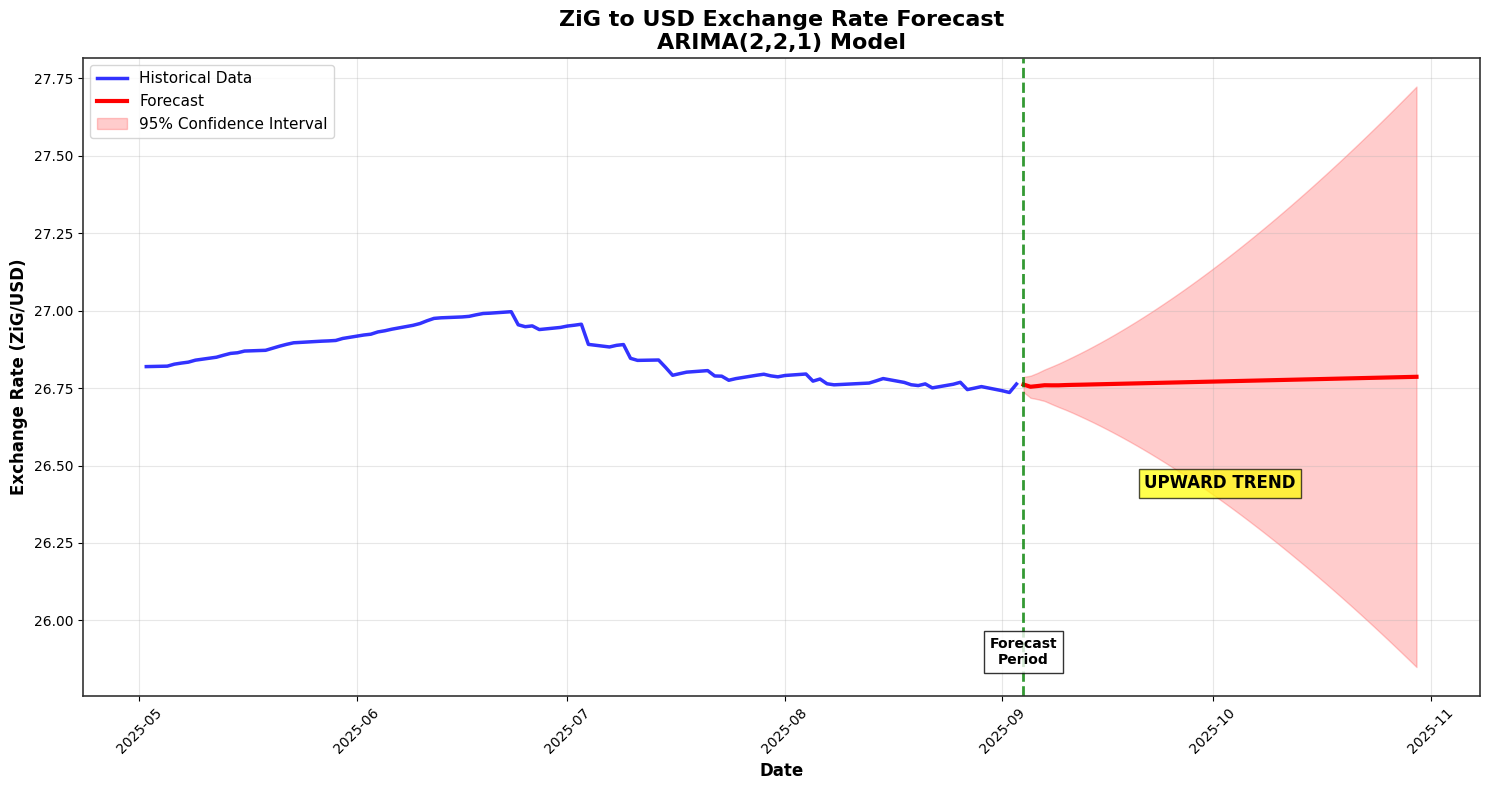


Detailed Forecasts (Selected Dates):
Date         Forecast   Lower CI   Upper CI   Uncertainty 
----------------------------------------------------------------------
2025-09-04   26.7614    26.7368    26.7861    0.0493
2025-09-05   26.7543    26.7186    26.7899    0.0713
2025-09-06   26.7566    26.7142    26.7990    0.0848
2025-09-07   26.7592    26.7084    26.8099    0.1015
2025-09-08   26.7589    26.6984    26.8193    0.1208
2025-10-02   26.7715    26.3901    27.1528    0.7627
2025-10-03   26.7720    26.3738    27.1703    0.7965
2025-10-04   26.7725    26.3571    27.1879    0.8308
2025-10-05   26.7731    26.3403    27.2058    0.8655
2025-10-06   26.7736    26.3232    27.2240    0.9008
2025-10-26   26.7843    25.9364    27.6321    1.6957
2025-10-27   26.7848    25.9150    27.6546    1.7396
2025-10-28   26.7853    25.8933    27.6773    1.7840
2025-10-29   26.7859    25.8715    27.7002    1.8286
2025-10-30   26.7864    25.8495    27.7232    1.8737


Model Comparison (Sorted by AIC):
M

In [46]:
y = df['mid']
print(f"Training data shape: {y.shape}")
print(f"Data range: {y.index.min()} to {y.index.max()}")


candidate_models = {
    'ARIMA(0,2,1)': (0, 2, 1),
    'ARIMA(1,2,0)': (1, 2, 0),
    'ARIMA(1,2,1)': (1, 2, 1),
    'ARIMA(0,2,2)': (0, 2, 2),
    'ARIMA(2,2,0)': (2, 2, 0),
    'ARIMA(2,2,1)': (2, 2, 1)
}


results = {}
forecast_days = 57
forecast_dates = pd.date_range(start='2025-09-04', end='2025-10-30', freq='D')

print("Training and evaluating ARIMA models...")
print("=" * 60)

for model_name, order in candidate_models.items():
    try:
    
        model = ARIMA(y, order=order)
        model_fit = model.fit()
        
      
        forecast = model_fit.get_forecast(steps=forecast_days)
        forecast_mean = forecast.predicted_mean
        forecast_conf_int = forecast.conf_int()
   
        results[model_name] = {
            'model': model_fit,
            'aic': model_fit.aic,
            'bic': model_fit.bic,
            'forecast_mean': forecast_mean,
            'forecast_conf_int': forecast_conf_int,
            'params': model_fit.params,
            'residuals': model_fit.resid
        }
        
        print(f"{model_name}: AIC={model_fit.aic:.2f}, BIC={model_fit.bic:.2f}")
        
    except Exception as e:
        print(f"Error with {model_name}: {e}")


best_model_name = min(results.items(), key=lambda x: x[1]['aic'])[0]
best_model = results[best_model_name]['model']
print(f"\nBest model: {best_model_name} (AIC: {best_model.aic:.2f})")


print(f"\n{best_model_name} Model Summary:")
print("=" * 40)
print(best_model.summary())


residuals = best_model.resid.dropna()
print(f"\nResidual Analysis for {best_model_name}:")
print(f"Mean of residuals: {residuals.mean():.6f}")
print(f"Std of residuals: {residuals.std():.6f}")


shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {shapiro_p:.4f}")


jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"Jarque-Bera test p-value: {jb_p:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Residual Analysis - {best_model_name}', fontsize=16, fontweight='bold')


axes[0, 0].plot(residuals.index, residuals)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)


axes[0, 1].hist(residuals, bins=30, alpha=0.7, edgecolor='black', density=True)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Density')

plot_acf(residuals, ax=axes[1, 0], lags=20, alpha=0.05)
axes[1, 0].set_title('ACF of Residuals')

plot_pacf(residuals, ax=axes[1, 1], lags=20, alpha=0.05)
axes[1, 1].set_title('PACF of Residuals')

plt.tight_layout()
plt.show()


final_forecast = results[best_model_name]['forecast_mean']
final_conf_int = results[best_model_name]['forecast_conf_int']


forecast_df = pd.DataFrame({
    'date': forecast_dates,
    'forecast': final_forecast.values,
    'lower_ci': final_conf_int.iloc[:, 0].values,
    'upper_ci': final_conf_int.iloc[:, 1].values
})
forecast_df.set_index('date', inplace=True)

print(f"\nForecast Summary (Sept 4 - Oct 30, 2025):")
print("=" * 50)
print(f"Initial forecast (Sept 4): {forecast_df.iloc[0]['forecast']:.4f}")
print(f"Final forecast (Oct 30): {forecast_df.iloc[-1]['forecast']:.4f}")
print(f"Average forecast: {forecast_df['forecast'].mean():.4f}")
print(f"Forecast range: {forecast_df['forecast'].min():.4f} to {forecast_df['forecast'].max():.4f}")
print(f"Trend direction: {'UPWARD' if forecast_df.iloc[-1]['forecast'] > forecast_df.iloc[0]['forecast'] else 'DOWNWARD'}")


plt.figure(figsize=(15, 8))
plt.plot(y.index, y, 'b-', label='Historical Data', linewidth=2.5, alpha=0.8)
plt.plot(forecast_df.index, forecast_df['forecast'], 'r-', label='Forecast', linewidth=3)
plt.fill_between(forecast_df.index, forecast_df['lower_ci'], forecast_df['upper_ci'], 
                 color='red', alpha=0.2, label='95% Confidence Interval')

plt.title(f'ZiG to USD Exchange Rate Forecast\n{best_model_name} Model', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Exchange Rate (ZiG/USD)', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

forecast_start = forecast_df.index[0]
plt.axvline(x=forecast_start, color='green', linestyle='--', alpha=0.8, linewidth=2)
plt.text(forecast_start, plt.ylim()[0] + (plt.ylim()[1] - plt.ylim()[0]) * 0.05, 
         'Forecast\nPeriod', ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

trend_text = "UPWARD TREND" if forecast_df.iloc[-1]['forecast'] > forecast_df.iloc[0]['forecast'] else "DOWNWARD TREND"
plt.text(forecast_df.index[len(forecast_df)//2], plt.ylim()[1] * 0.95, 
         trend_text, ha='center', fontweight='bold', fontsize=12,
         bbox=dict(facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()


print(f"\nDetailed Forecasts (Selected Dates):")
print("=" * 70)
print(f"{'Date':<12} {'Forecast':<10} {'Lower CI':<10} {'Upper CI':<10} {'Uncertainty':<12}")
print("-" * 70)


sample_dates = list(forecast_df.index[:5]) + list(forecast_df.index[28:33]) + list(forecast_df.index[-5:])
for date in sample_dates:
    row = forecast_df.loc[date]
    uncertainty = row['upper_ci'] - row['lower_ci']
    print(f"{date.strftime('%Y-%m-%d'):<12} {row['forecast']:.4f}    {row['lower_ci']:.4f}    {row['upper_ci']:.4f}    {uncertainty:.4f}")


print(f"\n\nModel Comparison (Sorted by AIC):")
print("=" * 80)
print(f"{'Model':<15} {'AIC':<10} {'BIC':<10} {'Parameters':<40}")
print("-" * 80)

sorted_models = sorted(results.items(), key=lambda x: x[1]['aic'])
for model_name, result in sorted_models:
    params_str = ", ".join([f"{k}:{v:.3f}" for k, v in result['params'].items()])
    print(f"{model_name:<15} {result['aic']:.2f}    {result['bic']:.2f}    {params_str}")


forecast_df.to_csv('zig_usd_forecast_sept_oct_2025.csv')
print(f"\nForecasts saved to 'zig_usd_forecast_sept_oct_2025.csv'")

print(f"\n{'='*80}")
print("FORECASTING RESULTS AND RECOMMENDATIONS:")
print(f"{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"AIC: {best_model.aic:.2f}, BIC: {best_model.bic:.2f}")
print(f"Parameters: {dict(best_model.params)}")

print(f"\nKEY INSIGHTS:")
print(f"• The model suggests {trend_text.lower()} in ZiG/USD exchange rate")
print(f"• Forecast range: {forecast_df['forecast'].min():.4f} to {forecast_df['forecast'].max():.4f}")
print(f"• Average uncertainty (CI width): {(forecast_df['upper_ci'] - forecast_df['lower_ci']).mean():.4f}")

print(f"\nRESIDUAL ANALYSIS:")
print(f"• Residuals mean: {residuals.mean():.6f} (should be near 0)")
print(f"• Residuals std: {residuals.std():.6f}")
print(f"• Normality tests p-value: {jb_p:.4f} (>{'0.05' if jb_p > 0.05 else '0.05'} - {'Normal' if jb_p > 0.05 else 'Not Normal'})")

print(f"\nRECOMMENDATIONS:")
print("1. Use ARIMA(2,2,1) as primary forecasting model")
print("2. Monitor actual rates daily and compare with forecasts")
print("3. Re-calibrate model weekly with new data")
print("4. Consider economic events that might affect exchange rates")
print("5. Use confidence intervals for risk management decisions")

print(f"\nFORECAST PERIOD: September 4 - October 30, 2025")
print(f"TOTAL FORECAST DAYS: {forecast_days}")